In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find repo root robustly from the notebook location.
cwd = Path.cwd().resolve()

repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "tnp_crps").exists() and (candidate / "experiments").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from cwd={cwd}")

print("Notebook cwd:", cwd)
print("Repo root:", repo_root)

RESULT_DIR = (
    repo_root
    / "results"
    / "synthetic_1d"
    / "all_metrics_all_models_4096_m64_b16"
)

metrics_path = RESULT_DIR / "metrics.csv"

print("Metrics path:", metrics_path)
print("Exists:", metrics_path.exists())

metrics = pd.read_csv(metrics_path)

metrics["coverage90_error"] = metrics["coverage_90"] - 0.90
metrics["ssr_error"] = metrics["spread_skill_ratio"] - 1.0

print(metrics.shape)
metrics.head()

Notebook cwd: /rds/user/ij292/hpc-work/tnp-crps/notebooks
Repo root: /rds/user/ij292/hpc-work/tnp-crps
Metrics path: /rds/user/ij292/hpc-work/tnp-crps/results/synthetic_1d/all_metrics_all_models_4096_m64_b16/metrics.csv
Exists: True
(432, 164)


,model_name,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,ensemble_spread,spread_skill_ratio,...,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob,coverage90_error,ssr_error
0,dropout_crps_m2_p005,matern12,all,all,64,524288,0.778726,0.402319,0.767182,0.992842,...,0.015804,0.015862,0.016144,0.016140,0.016218,0.016243,0.017086,0.017994,-0.037697,-0.007158
1,dropout_crps_m2_p005,matern12,all,nc_001_004,64,30720,0.948849,0.525099,0.917081,0.974041,...,0.016178,0.015592,0.016178,0.016374,0.017220,0.018294,0.019499,0.022233,-0.051042,-0.025959
2,dropout_crps_m2_p005,matern12,all,nc_005_016,64,114688,0.853076,0.461387,0.809676,0.956512,...,0.016026,0.015407,0.016767,0.017011,0.017831,0.018380,0.020569,0.026707,-0.070000,-0.043488
3,dropout_crps_m2_p005,matern12,all,nc_017_064,64,378880,0.738823,0.374484,0.740144,1.009585,...,0.015707,0.016021,0.015952,0.015857,0.015649,0.015430,0.015836,0.015013,-0.026837,0.009585
4,dropout_crps_m2_p005,matern12,extrapolation,all,64,262106,0.971666,0.542083,0.963718,0.999539,...,0.015585,0.015219,0.015234,0.014715,0.014944,0.014845,0.015723,0.016028,-0.026746,-0.000461


In [3]:
# Sanity check: did the evaluator produce one row per
# model × eval_set × region × context_bucket combination?

unique_groups = metrics[
    ["model_name", "eval_set", "region", "context_bucket"]
].drop_duplicates()

print("Unique metric groups:", unique_groups.shape)
print("Total metric rows:", metrics.shape)

duplicate_count = metrics.duplicated(
    subset=["model_name", "eval_set", "region", "context_bucket"]
).sum()

print("Duplicate groups:", duplicate_count)

Unique metric groups: (432, 4)
Total metric rows: (432, 164)
Duplicate groups: 0


## Labels and formatting

In [2]:
MODEL_ORDER = [
    "gaussian_tnp_nll",
    "dropout_crps_m4_p005",
    "dropout_crps_m2_p005",
    "dropout_crps_m2_p010",
    "stochln_crps_m4",
    "stochln_crps_m2",
]

MODEL_LABELS = {
    "gaussian_tnp_nll": "Gaussian TNP NLL",
    "dropout_crps_m4_p005": "Dropout CRPS M=4 p=.05",
    "dropout_crps_m2_p005": "Dropout CRPS M=2 p=.05",
    "dropout_crps_m2_p010": "Dropout CRPS M=2 p=.10",
    "stochln_crps_m4": "StochLN CRPS M=4",
    "stochln_crps_m2": "StochLN CRPS M=2",
}

EVAL_LABELS = {
    "mixture": "Mixture",
    "rbf": "RBF",
    "matern12": "Matérn-1/2",
    "matern32": "Matérn-3/2",
    "matern52": "Matérn-5/2",
    "periodic": "Periodic",
}

def add_display_labels(df):
    out = df.copy()
    out["Model"] = out["model_name"].map(MODEL_LABELS).fillna(out["model_name"])
    out["Eval set"] = out["eval_set"].map(EVAL_LABELS).fillna(out["eval_set"])
    out["model_order"] = out["model_name"].map({m: i for i, m in enumerate(MODEL_ORDER)})
    return out.sort_values(["model_order", "eval_set"])

def round_table(df, digits=3):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].round(digits)
    return out

def save_table_png(df, title, output_path, font_size=9, scale_y=1.35):
    fig_width = max(9, 1.3 * len(df.columns))
    fig_height = max(2.5, 0.45 * len(df) + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=14, pad=14)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, scale_y)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eeeeee")

    fig.tight_layout()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

    return output_path

### Main mixture table, all variants

In [4]:
main_mixture = metrics.query(
    "eval_set == 'mixture' and region == 'all' and context_bucket == 'all'"
).copy()

main_mixture = add_display_labels(main_mixture)

slide3_table = main_mixture[
    [
        "Model",
        "rmse_pooled",
        "crps",
        "spread_skill_ratio",
        "coverage_90",
        "width_90",
    ]
].rename(
    columns={
        "rmse_pooled": "RMSE ↓",
        "crps": "CRPS ↓",
        "spread_skill_ratio": "SSR ≈ 1",
        "coverage_90": "Cov90 ≈ .90",
        "width_90": "Width90 ↓",
    }
)

slide3_table = round_table(slide3_table, digits=3)

slide3_csv = RESULT_DIR / "slide3_main_mixture_all_variants.csv"
slide3_png = RESULT_DIR / "slide3_main_mixture_all_variants.png"

slide3_table.to_csv(slide3_csv, index=False)
save_table_png(
    slide3_table,
    "Main Gaussian-control results: five-kernel mixture",
    slide3_png,
    font_size=9,
)

slide3_table

,Model,RMSE ↓,CRPS ↓,SSR ≈ 1,Cov90 ≈ .90,Width90 ↓
252,Gaussian TNP NLL,0.661,0.300,0.994,0.874,1.662
180,Dropout CRPS M=4 p=.05,0.662,0.301,1.000,0.880,1.692
36,Dropout CRPS M=2 p=.05,0.662,0.301,1.003,0.881,1.698
108,Dropout CRPS M=2 p=.10,0.661,0.301,1.004,0.882,1.702
396,StochLN CRPS M=4,0.671,0.309,1.016,0.881,1.764
324,StochLN CRPS M=2,0.682,0.318,1.079,0.898,1.923


### Selected per-kernel table

In [7]:
SELECTED_MODELS = [
    "gaussian_tnp_nll",
    "dropout_crps_m4_p005",
    "dropout_crps_m2_p010",
    "stochln_crps_m4",
]

SELECTED_EVALS = [
    "mixture",
    "rbf",
    "matern52",
    "periodic",
]

kernel_subset = metrics.query(
    "region == 'all' and context_bucket == 'all' "
    "and model_name in @SELECTED_MODELS and eval_set in @SELECTED_EVALS"
).copy()

kernel_subset = add_display_labels(kernel_subset)

# CRPS table
crps_kernel_table = kernel_subset.pivot(
    index="Model",
    columns="Eval set",
    values="crps",
).loc[[MODEL_LABELS[m] for m in SELECTED_MODELS], [EVAL_LABELS[e] for e in SELECTED_EVALS]]

crps_kernel_table = crps_kernel_table.round(3).reset_index()
crps_kernel_table.columns.name = None

crps_csv = RESULT_DIR / "slide_kernel_crps_selected.csv"
crps_png = RESULT_DIR / "slide_kernel_crps_selected.png"

crps_kernel_table.to_csv(crps_csv, index=False)
save_table_png(
    crps_kernel_table,
    "CRPS by evaluation kernel",
    crps_png,
    font_size=9,
)

crps_kernel_table

,Model,Mixture,RBF,Matérn-5/2,Periodic
0,Gaussian TNP NLL,0.300,0.302,0.322,0.145
1,Dropout CRPS M=4 p=.05,0.301,0.303,0.323,0.148
2,Dropout CRPS M=2 p=.10,0.301,0.304,0.323,0.146
3,StochLN CRPS M=4,0.309,0.310,0.326,0.173


In [8]:
rmse_kernel_table = kernel_subset.pivot(
    index="Model",
    columns="Eval set",
    values="rmse_pooled",
).loc[[MODEL_LABELS[m] for m in SELECTED_MODELS], [EVAL_LABELS[e] for e in SELECTED_EVALS]]

rmse_kernel_table = rmse_kernel_table.round(3).reset_index()
rmse_kernel_table.columns.name = None

rmse_csv = RESULT_DIR / "slide_kernel_rmse_selected.csv"
rmse_png = RESULT_DIR / "slide_kernel_rmse_selected.png"

rmse_kernel_table.to_csv(rmse_csv, index=False)
save_table_png(
    rmse_kernel_table,
    "RMSE by evaluation kernel",
    rmse_png,
    font_size=9,
)

rmse_kernel_table

,Model,Mixture,RBF,Matérn-5/2,Periodic
0,Gaussian TNP NLL,0.661,0.671,0.697,0.360
1,Dropout CRPS M=4 p=.05,0.662,0.672,0.698,0.370
2,Dropout CRPS M=2 p=.10,0.661,0.672,0.698,0.364
3,StochLN CRPS M=4,0.671,0.680,0.702,0.417


### Dispersion/calibration table for mixture

In [9]:
dispersion_mixture = metrics.query(
    "eval_set == 'mixture' and region == 'all' and context_bucket == 'all'"
).copy()

dispersion_mixture = add_display_labels(dispersion_mixture)

slide4_dispersion_table = dispersion_mixture[
    [
        "Model",
        "ensemble_spread",
        "spread_skill_ratio",
        "coverage_90",
        "coverage90_error",
        "width_90",
    ]
].rename(
    columns={
        "ensemble_spread": "Spread",
        "spread_skill_ratio": "SSR ≈ 1",
        "coverage_90": "Cov90 ≈ .90",
        "coverage90_error": "Cov90 - .90",
        "width_90": "Width90 ↓",
    }
)

slide4_dispersion_table = round_table(slide4_dispersion_table, digits=3)

slide4_csv = RESULT_DIR / "slide4_mixture_dispersion_table.csv"
slide4_png = RESULT_DIR / "slide4_mixture_dispersion_table.png"

slide4_dispersion_table.to_csv(slide4_csv, index=False)
save_table_png(
    slide4_dispersion_table,
    "Dispersion/calibration on five-kernel mixture",
    slide4_png,
    font_size=9,
)

slide4_dispersion_table

,Model,Spread,SSR ≈ 1,Cov90 ≈ .90,Cov90 - .90,Width90 ↓
252,Gaussian TNP NLL,0.652,0.994,0.874,-0.026,1.662
180,Dropout CRPS M=4 p=.05,0.657,1.000,0.880,-0.020,1.692
36,Dropout CRPS M=2 p=.05,0.658,1.003,0.881,-0.019,1.698
108,Dropout CRPS M=2 p=.10,0.658,1.004,0.882,-0.018,1.702
396,StochLN CRPS M=4,0.676,1.016,0.881,-0.019,1.764
324,StochLN CRPS M=2,0.731,1.079,0.898,-0.002,1.923


### Coverage-curve panel

In [7]:
def plot_coverage_panel(
    df,
    eval_set="mixture",
    regions=("all", "interpolation", "extrapolation"),
    context_bucket="all",
    models=None,
    output_path=None,
):
    if models is None:
        models = MODEL_ORDER

    levels = np.array([0.50, 0.80, 0.90, 0.95])
    coverage_cols = ["coverage_50", "coverage_80", "coverage_90", "coverage_95"]

    fig, axes = plt.subplots(
        1,
        len(regions),
        figsize=(5.2 * len(regions), 4.2),
        sharey=True,
    )

    if len(regions) == 1:
        axes = [axes]

    for ax, region in zip(axes, regions):
        subset = df.query(
            "eval_set == @eval_set and region == @region and context_bucket == @context_bucket"
        ).copy()

        # This is the important missing line.
        subset = subset[subset["model_name"].isin(models)].copy()

        subset["model_order"] = subset["model_name"].map(
            {m: i for i, m in enumerate(models)}
        )
        subset = subset.sort_values("model_order")

        for _, row in subset.iterrows():
            empirical = [row[c] for c in coverage_cols]
            ax.plot(
                levels,
                empirical,
                marker="o",
                linewidth=1.8,
                label=MODEL_LABELS.get(row["model_name"], row["model_name"]),
            )

        ax.plot(
            levels,
            levels,
            linestyle="--",
            color="black",
            linewidth=1.2,
            label="Ideal",
        )
        ax.set_title(f"{EVAL_LABELS.get(eval_set, eval_set)}: {region}", fontsize=18, pad=10)
        ax.set_xlabel("Nominal coverage", fontsize=15)
        ax.tick_params(axis="both", labelsize=13)
        ax.grid(True, alpha=0.35)

    axes[0].set_ylabel("Empirical coverage", fontsize=15)

    # Collect legend entries from all panels, not just axes[0].
    handles = []
    labels = []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    by_label = dict(zip(labels, handles))

    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        ncol=3,
        fontsize=15,
        markerscale=1.25,
        handlelength=2.0,
        handletextpad=0.6,
        columnspacing=1.2,
        bbox_to_anchor=(0.5, 1.10),
        frameon=True,
        )

    fig.tight_layout(rect=(0, 0, 1, 0.84))

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=250, bbox_inches="tight")
        fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")

    return fig



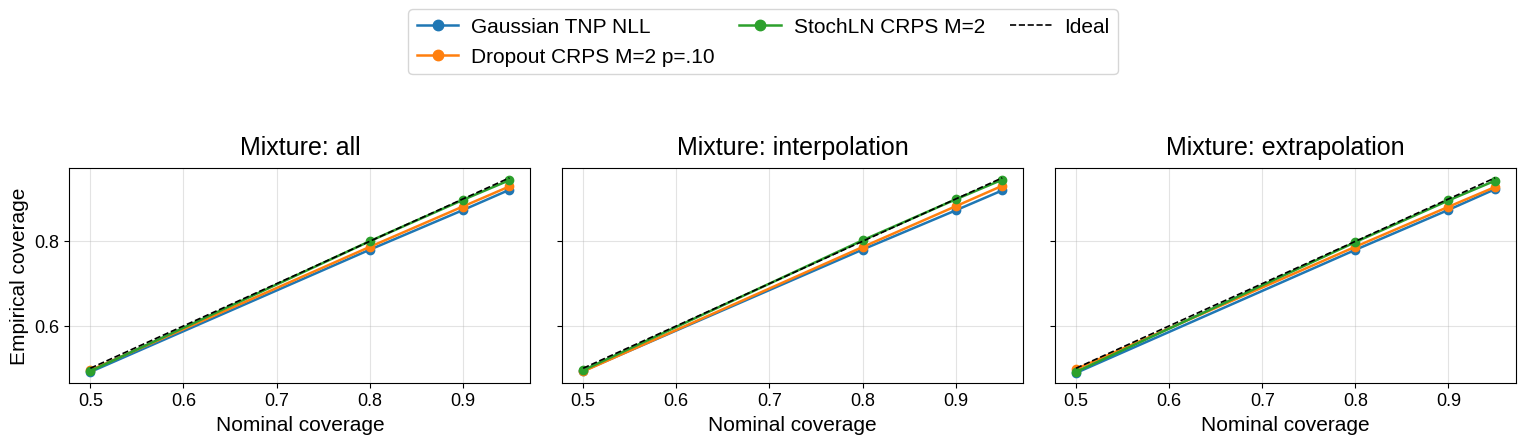

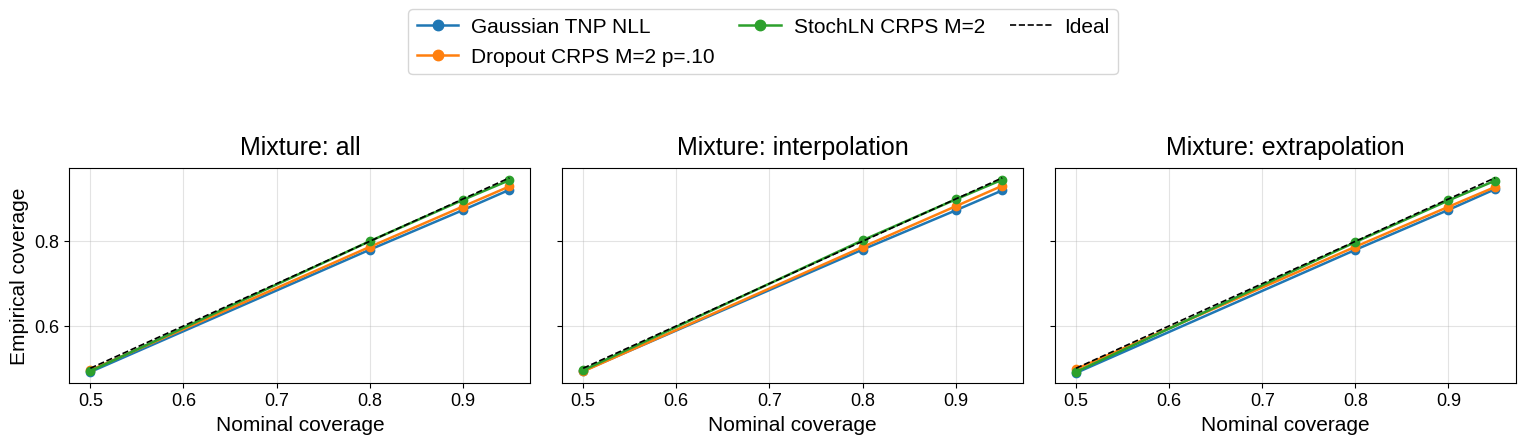

In [8]:
SELECTED_FOR_CALIBRATION = [
    "gaussian_tnp_nll",
    # "dropout_crps_m4_p005",
    # "dropout_crps_m2_p005",
    "dropout_crps_m2_p010",
    # "stochln_crps_m4",
    "stochln_crps_m2",
]

coverage_panel_path = RESULT_DIR / "slide4_mixture_coverage_panel_poster.png"

fig = plot_coverage_panel(
    metrics,
    eval_set="mixture",
    regions=("all", "interpolation", "extrapolation"),
    models=SELECTED_FOR_CALIBRATION,
    output_path=coverage_panel_path,
)

fig

### Width vs coverage

In [5]:

SELECTED_FOR_SHARPNESS = [
    "gaussian_tnp_nll",
    "dropout_crps_m4_p005",
    "dropout_crps_m2_p010",
    "stochln_crps_m4",
    "stochln_crps_m2",
]


def plot_sharpness_calibration(
    df,
    eval_set="mixture",
    region="all",
    context_bucket="all",
    models=SELECTED_FOR_SHARPNESS,
    output_path=None,
):
    """
    Plot the trade-off between 90% interval sharpness and calibration.

    x-axis:
        Width90. Further left means narrower, sharper intervals.

    y-axis:
        Cov90. Values closer to 0.90 indicate better calibration.
    """

    required_columns = {
        "model_name",
        "eval_set",
        "region",
        "context_bucket",
        "width_90",
        "coverage_90",
    }

    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    subset = df.query(
        "eval_set == @eval_set and "
        "region == @region and "
        "context_bucket == @context_bucket"
    ).copy()

    subset = subset[
        subset["model_name"].isin(models)
    ].copy()

    if subset.empty:
        raise ValueError(
            "No matching rows found for the requested "
            "evaluation set, region, context bucket and models."
        )

    # Check that each model contributes one point.
    duplicates = subset.duplicated(
        subset=["model_name"],
        keep=False,
    )

    if duplicates.any():
        duplicate_models = sorted(
            subset.loc[duplicates, "model_name"].unique()
        )
        raise ValueError(
            "Expected one row per model, but found duplicates for: "
            f"{duplicate_models}"
        )

    model_order = {
        model_name: index
        for index, model_name in enumerate(models)
    }

    subset["model_order"] = subset["model_name"].map(
        model_order
    )
    subset = subset.sort_values("model_order")

    # Poster-scale sizing and typography.
    plt.rcParams.update(
        {
            "font.family": "Liberation Sans",
            "font.size": 18,
            "axes.titlesize": 24,
            "axes.labelsize": 21,
            "xtick.labelsize": 17,
            "ytick.labelsize": 17,
            "legend.fontsize": 16,
        }
    )

    fig, ax = plt.subplots(figsize=(10.5, 7.5))

    for _, row in subset.iterrows():
        label = MODEL_LABELS.get(
            row["model_name"],
            row["model_name"],
        )

        ax.scatter(
            row["width_90"],
            row["coverage_90"],
            s=190,
            edgecolor="black",
            linewidth=0.8,
            label=label,
            zorder=3,
        )

    # Nominal 90% coverage reference.
    ax.axhline(
        0.90,
        linestyle="--",
        linewidth=2.0,
        color="black",
        label="Nominal 90% coverage",
        zorder=1,
    )

    ax.set_xlabel(
        "Mean width of central 90% predictive interval"
    )
    ax.set_ylabel(
        "Empirical coverage of 90% predictive interval"
    )

    ax.set_title(
        "Sharpness–calibration trade-off\n"
        "Five-kernel GP mixture",
        pad=14,
    )

    # Leave a small margin around the observed points.
    x_min = subset["width_90"].min()
    x_max = subset["width_90"].max()
    x_margin = max(0.04, 0.12 * (x_max - x_min))

    ax.set_xlim(
        x_min - x_margin,
        x_max + x_margin,
    )

    y_min = min(
        0.865,
        subset["coverage_90"].min() - 0.008,
    )
    y_max = max(
        0.907,
        subset["coverage_90"].max() + 0.008,
    )

    ax.set_ylim(y_min, y_max)

    ax.grid(
        True,
        alpha=0.30,
        linewidth=0.9,
    )

    ax.legend(
        loc="best",
        frameon=True,
        markerscale=0.9,
        handletextpad=0.6,
        borderpad=0.7,
        labelspacing=0.5,
    )

    # Interpretation cues.
    ax.text(
        0.02,
        0.03,
        "← sharper intervals",
        transform=ax.transAxes,
        fontsize=17,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            output_path.with_suffix(".pdf"),
            bbox_inches="tight",
        )

    return fig, subset

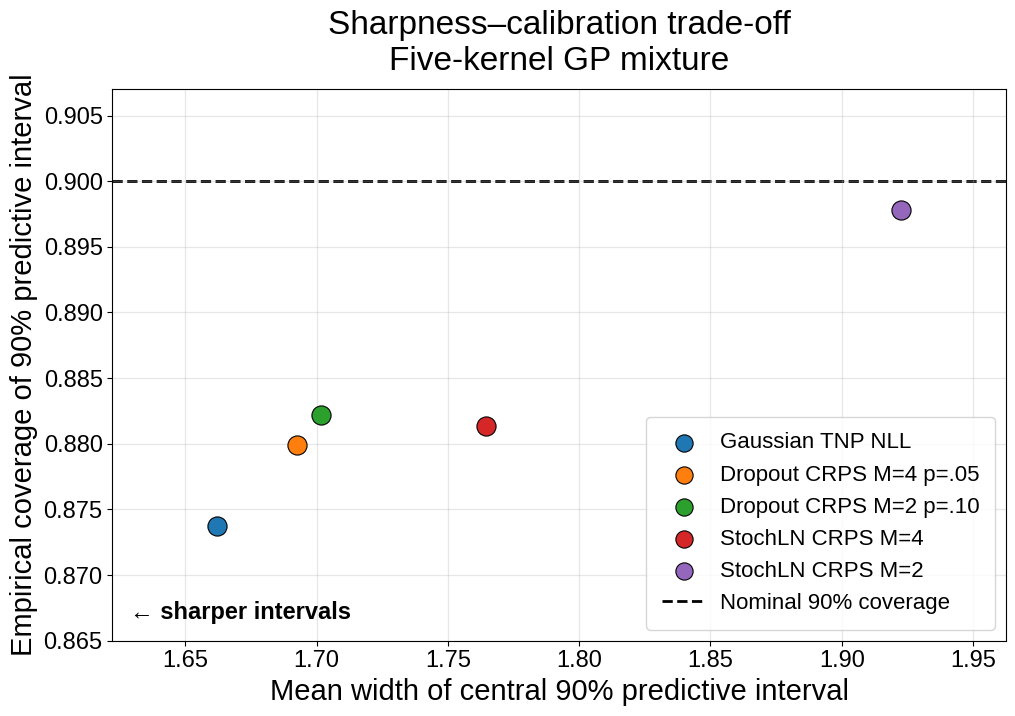

,model_name,width_90,coverage_90
252,gaussian_tnp_nll,1.662273,0.873705
180,dropout_crps_m4_p005,1.692440,0.879892
108,dropout_crps_m2_p010,1.701758,0.882215
396,stochln_crps_m4,1.764359,0.881357
324,stochln_crps_m2,1.922540,0.897823


In [6]:
sharpness_calibration_path = (
    RESULT_DIR
    / "sharpness_calibration_mixture.png"
)

fig, sharpness_table = plot_sharpness_calibration(
    metrics,
    eval_set="mixture",
    region="all",
    context_bucket="all",
    models=SELECTED_FOR_SHARPNESS,
    output_path=sharpness_calibration_path,
)

plt.show()

sharpness_table[
    [
        "model_name",
        "width_90",
        "coverage_90",
    ]
]

In [18]:
# main aggregate table
main = metrics.query("region == 'all' and context_bucket == 'all'")

cols = [
    "model_name",
    "eval_set",
    "rmse_pooled",
    "crps",
    "ensemble_spread",
    "spread_skill_ratio",
    "coverage_90",
    "coverage90_error",
    "width_90",
]

print(main[cols].sort_values(["eval_set", "model_name"]).to_string(index=False))

          model_name eval_set  rmse_pooled     crps  ensemble_spread  spread_skill_ratio  coverage_90  coverage90_error  width_90
dropout_crps_m2_p005 matern12     0.778726 0.402319         0.767182            0.992842     0.862303         -0.037697  2.207831
dropout_crps_m2_p010 matern12     0.779129 0.402854         0.768193            0.993636     0.863007         -0.036993  2.217745
dropout_crps_m4_p005 matern12     0.778870 0.402301         0.766815            0.992185     0.860432         -0.039568  2.199055
    gaussian_tnp_nll matern12     0.777624 0.400116         0.762673            0.988406     0.859934         -0.040066  2.182877
     stochln_crps_m2 matern12     0.783690 0.408072         0.804735            1.034844     0.833445         -0.066555  2.229641
     stochln_crps_m4 matern12     0.781492 0.405566         0.765378            0.987002     0.832747         -0.067253  2.152603
dropout_crps_m2_p005 matern32     0.713942 0.337405         0.712223            1.005355  

In [20]:
# Best model by CRPS per evaluation set
best_crps = (
    main.sort_values("crps")
    .groupby("eval_set", as_index=False)
    .first()
)

best_crps[
    [
        "eval_set",
        "model_name",
        "rmse_pooled",
        "crps",
        "spread_skill_ratio",
        "coverage_90",
        "width_90",
    ]
]

,eval_set,model_name,rmse_pooled,crps,spread_skill_ratio,coverage_90,width_90
0,matern12,gaussian_tnp_nll,0.777624,0.400116,0.988406,0.859934,2.182877
1,matern32,gaussian_tnp_nll,0.714321,0.336902,0.999399,0.871521,1.875296
2,matern52,gaussian_tnp_nll,0.697186,0.321890,1.001051,0.878086,1.804018
3,mixture,gaussian_tnp_nll,0.660762,0.299930,0.993819,0.873705,1.662273
4,periodic,gaussian_tnp_nll,0.359899,0.144558,1.071923,0.883730,0.854410
5,rbf,gaussian_tnp_nll,0.670572,0.302123,1.002679,0.883944,1.706666


### Interpolation vs extrapolation

In [24]:

region_table = metrics.query("context_bucket == 'all'").copy()

region_cols = [
    "model_name",
    "eval_set",
    "region",
    "rmse_pooled",
    "crps",
    "spread_skill_ratio",
    "coverage_90",
    "coverage90_error",
    "width_90",
]

region_table[region_cols].sort_values(["eval_set", "region", "model_name"])

,model_name,eval_set,region,rmse_pooled,crps,spread_skill_ratio,coverage_90,coverage90_error,width_90
0,dropout_crps_m2_p005,matern12,all,0.778726,0.402319,0.992842,0.862303,-0.037697,2.207831
72,dropout_crps_m2_p010,matern12,all,0.779129,0.402854,0.993636,0.863007,-0.036993,2.217745
144,dropout_crps_m4_p005,matern12,all,0.778870,0.402301,0.992185,0.860432,-0.039568,2.199055
216,gaussian_tnp_nll,matern12,all,0.777624,0.400116,0.988406,0.859934,-0.040066,2.182877
288,stochln_crps_m2,matern12,all,0.783690,0.408072,1.034844,0.833445,-0.066555,2.229641
...,...,...,...,...,...,...,...,...,...
140,dropout_crps_m2_p010,rbf,interpolation,0.307237,0.120747,1.071827,0.899760,-0.000240,0.743457
212,dropout_crps_m4_p005,rbf,interpolation,0.306410,0.120466,1.072244,0.899146,-0.000854,0.740037
284,gaussian_tnp_nll,rbf,interpolation,0.303513,0.119274,1.055742,0.892556,-0.007444,0.713831
356,stochln_crps_m2,rbf,interpolation,0.319861,0.128925,1.280724,0.938470,0.038470,0.957145


In [28]:
# extrapolation table
extrap = metrics.query("region == 'extrapolation' and context_bucket == 'all'").copy()

extrap[
    [
        "model_name",
        "eval_set",
        "rmse_pooled",
        "crps",
        "spread_skill_ratio",
        "coverage_90",
        "coverage90_error",
        "width_90",
    ]
].sort_values(["eval_set", "model_name"])

,model_name,eval_set,rmse_pooled,crps,spread_skill_ratio,coverage_90,coverage90_error,width_90
4,dropout_crps_m2_p005,matern12,0.971666,0.542083,0.999539,0.873254,-0.026746,3.018270
76,dropout_crps_m2_p010,matern12,0.971949,0.542297,1.001499,0.873387,-0.026613,3.028652
148,dropout_crps_m4_p005,matern12,0.972091,0.542159,0.999267,0.870316,-0.029684,3.001932
220,gaussian_tnp_nll,matern12,0.970964,0.541115,0.998286,0.870594,-0.029406,3.004174
292,stochln_crps_m2,matern12,0.977895,0.546892,1.060485,0.886004,-0.013996,3.192471
364,stochln_crps_m4,matern12,0.975239,0.544321,1.009785,0.874196,-0.025804,3.048361
16,dropout_crps_m2_p005,matern32,0.939505,0.518244,1.004807,0.873273,-0.026727,2.893560
88,dropout_crps_m2_p010,matern32,0.939667,0.518401,1.003614,0.873124,-0.026876,2.899809
160,dropout_crps_m4_p005,matern32,0.940007,0.518360,0.999513,0.871060,-0.028940,2.877993
232,gaussian_tnp_nll,matern32,0.940349,0.518111,1.000855,0.871701,-0.028299,2.884561


In [17]:
# Low-context table
low_context = metrics.query("region == 'all' and context_bucket == 'nc_001_004'").copy()

low_context[
    [
        "model_name",
        "eval_set",
        "rmse_pooled",
        "crps",
        "spread_skill_ratio",
        "coverage_90",
        "coverage90_error",
        "width_90",
        "numel",
    ]
].sort_values(["eval_set", "model_name"])

,model_name,eval_set,rmse_pooled,crps,spread_skill_ratio,coverage_90,coverage90_error,width_90,numel
1,dropout_crps_m2_p005,matern12,0.948849,0.525099,0.974041,0.848958,-0.051042,2.814912,30720
73,dropout_crps_m2_p010,matern12,0.949284,0.525160,0.977355,0.849642,-0.050358,2.824119,30720
145,dropout_crps_m4_p005,matern12,0.949839,0.525418,0.970752,0.847624,-0.052376,2.803896,30720
217,gaussian_tnp_nll,matern12,0.951773,0.525515,0.966936,0.843750,-0.056250,2.787377,30720
289,stochln_crps_m2,matern12,0.954587,0.527407,1.049231,0.876888,-0.023112,3.048197,30720
361,stochln_crps_m4,matern12,0.947263,0.522598,0.985528,0.854915,-0.045085,2.837749,30720
13,dropout_crps_m2_p005,matern32,0.926399,0.500839,0.992909,0.872168,-0.027832,2.797627,30720
85,dropout_crps_m2_p010,matern32,0.927020,0.501788,0.994628,0.871094,-0.028906,2.799968,30720
157,dropout_crps_m4_p005,matern32,0.927732,0.501606,0.990006,0.870313,-0.029687,2.786997,30720
229,gaussian_tnp_nll,matern32,0.927393,0.501216,0.988497,0.868555,-0.031445,2.774110,30720


In [18]:
# Underdispersion flags
underdispersion_flags = metrics.query(
    "coverage_90 < 0.88 or spread_skill_ratio < 0.95"
).copy()

underdispersion_flags[
    [
        "model_name",
        "eval_set",
        "region",
        "context_bucket",
        "rmse_pooled",
        "crps",
        "spread_skill_ratio",
        "coverage_90",
        "coverage90_error",
        "width_90",
        "numel",
    ]
].sort_values(["coverage_90", "spread_skill_ratio"])

,model_name,eval_set,region,context_bucket,rmse_pooled,crps,spread_skill_ratio,coverage_90,coverage90_error,width_90,numel
370,stochln_crps_m4,matern12,interpolation,nc_005_016,0.677960,0.367186,0.864586,0.751754,-0.148246,1.608931,57310
298,stochln_crps_m2,matern12,interpolation,nc_005_016,0.677183,0.366102,0.930513,0.769237,-0.130763,1.710422,57310
299,stochln_crps_m2,matern12,interpolation,nc_017_064,0.417796,0.222728,0.904124,0.777559,-0.122441,1.012211,189430
296,stochln_crps_m2,matern12,interpolation,all,0.521691,0.269293,0.939245,0.780900,-0.119100,1.267091,262182
368,stochln_crps_m4,matern12,interpolation,all,0.520065,0.266852,0.902359,0.791309,-0.108691,1.257105,262182
...,...,...,...,...,...,...,...,...,...,...,...
386,stochln_crps_m4,matern52,all,nc_005_016,0.772770,0.383779,1.001916,0.879726,-0.020274,2.169662,114688
180,dropout_crps_m4_p005,mixture,all,all,0.661662,0.301184,1.000335,0.879892,-0.020108,1.692440,524288
353,stochln_crps_m2,rbf,extrapolation,nc_001_004,1.048026,0.585994,1.026586,0.879958,-0.020042,3.362958,15278
294,stochln_crps_m2,matern12,extrapolation,nc_005_016,0.993209,0.557339,1.046364,0.879971,-0.020029,3.201731,57378


### Rank histogram

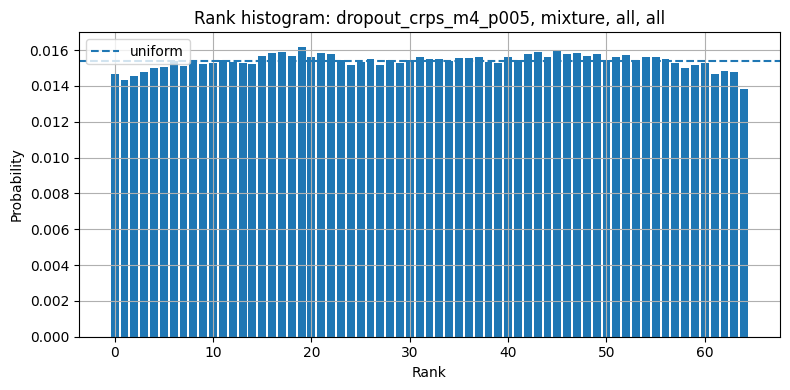

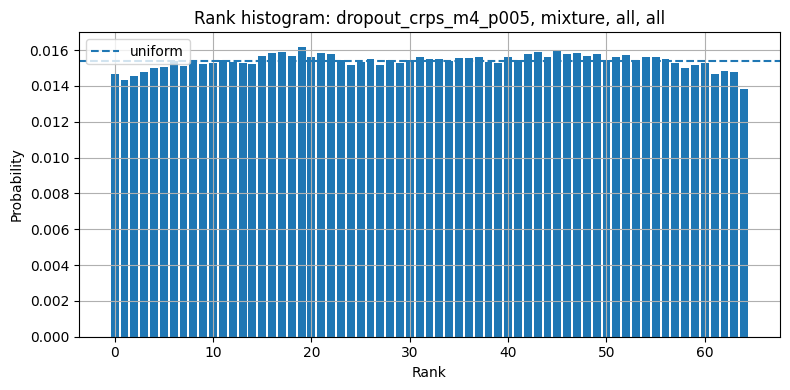

In [20]:
def get_rank_probs(row):
    rank_cols = sorted([c for c in row.index if c.startswith("rank_") and c.endswith("_prob")])
    probs = row[rank_cols].astype(float).to_numpy()
    return probs

def plot_rank_histogram(df, model_name, eval_set, region="all", context_bucket="all"):
    subset = df.query(
        "model_name == @model_name and eval_set == @eval_set and region == @region and context_bucket == @context_bucket"
    )

    if len(subset) != 1:
        raise ValueError(f"Expected one row, got {len(subset)}")

    row = subset.iloc[0]
    probs = get_rank_probs(row)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(len(probs)), probs)
    ax.axhline(1.0 / len(probs), linestyle="--", label="uniform")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Probability")
    ax.set_title(f"Rank histogram: {model_name}, {eval_set}, {region}, {context_bucket}")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    return fig

fig = plot_rank_histogram(metrics, "dropout_crps_m4_p005", "mixture")
fig

In [ ]:
# save teh fig
fig_path = (
    repo_root
    / "results"
    / "synthetic_1d"
    / "all_metrics_all_models_4096_m64_b16"
    / "rank_hist_dropout_m4_mixture_all.png"
)
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
fig_path